# Unified Schrödinger-Bridge Framework for Stochastic Volatility Calibration

## FANN + Optimal Transport + Schrödinger Bridges

This notebook implements a unified mathematical framework:
1. **Feed-anywhere ANN (FANN)** - Graph-based neural dynamics with Schrödinger equation evolution
2. **Optimal Transport (OT)** - For measure-preserving transformations
3. **Schrödinger Bridges** - For entropy-regularized optimal transport
4. **Stochastic Volatility Models** - Heston model calibration using Sinkhorn divergence

### Mathematical Foundation

The core unifying equation is the **controlled Schrödinger equation on graphs**:

$$i\lambda \partial_t \psi^{(\ell)} = -\frac{\lambda^2}{2} \Delta_{\Sigma^{(\ell)}} \psi^{(\ell)} + V_{\text{caSB}}^{(\ell)} \psi^{(\ell)}$$

where the potential $V_{\text{caSB}}$ encodes both the graph topology and the control objectives.

### Connection to Volatility Calibration

The probability density $\rho = |\psi|^2$ evolves according to a Fokker-Planck equation:

$$\partial_t \rho + \nabla \cdot (\rho \mathbf{v}) = \frac{1}{2} \Delta_{\Sigma} \rho$$

This is mathematically equivalent to the calibration problem where we seek to transform a reference measure (prior model) into a target measure (market-implied distribution) with minimal "energy" cost.

In [1]:
import numpy as np
import torch
import torch.optim as optim
from torch import nn
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import spsolve, eigsh
from scipy.interpolate import interp1d, RectBivariateSpline
from scipy.optimize import minimize, differential_evolution
from scipy.stats import norm
from scipy.integrate import solve_ivp
import yfinance as yf
import pandas as pd
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict, Callable
from abc import ABC, abstractmethod
import warnings
warnings.filterwarnings('ignore')

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Part 1: Core Mathematical Framework - Graph Schrödinger Dynamics

Implementation of the FANN framework with nonlinear Schrödinger equation on weighted graphs.

In [2]:
class GraphSobolevSpace:
    """
    Discrete Sobolev spaces on graphs for the FANN framework.
    Implements H^1(V) and H^2(V) spaces with proper inner products.
    """

    def __init__(self, n_vertices: int, edge_list: List[Tuple[int, int]],
                 vertex_weights: Optional[np.ndarray] = None,
                 edge_weights: Optional[np.ndarray] = None):
        """
        Initialize Sobolev space on graph.

        Args:
            n_vertices: Number of vertices |V|
            edge_list: List of edges (u, v) where u, v are vertex indices
            vertex_weights: Weight measure µ(v) for each vertex
            edge_weights: Weight measure ρ(e) for each edge
        """
        self.n_vertices = n_vertices
        self.edge_list = edge_list
        self.n_edges = len(edge_list)

        # Default uniform weights
        self.mu = vertex_weights if vertex_weights is not None else np.ones(n_vertices)
        self.rho = edge_weights if edge_weights is not None else np.ones(self.n_edges)

        # Build discrete gradient operator (incidence matrix)
        self._build_gradient_operator()

        # Build Laplacian operator
        self._build_laplacian()

    def _build_gradient_operator(self):
        """Build discrete gradient d: L^2(V) -> L^2(E) as sparse matrix."""
        rows, cols, data = [], [], []

        for edge_idx, (u, v) in enumerate(self.edge_list):
            # Oriented edge e = (v, u): (df)(e) = f(u) - f(v)
            rows.append(edge_idx)
            cols.append(u)
            data.append(1.0)

            rows.append(edge_idx)
            cols.append(v)
            data.append(-1.0)

        self.gradient = csr_matrix((data, (rows, cols)), shape=(self.n_edges, self.n_vertices))

        # Weighted gradient for L^2(E) inner product
        self.weighted_gradient = diags(np.sqrt(self.rho)) @ self.gradient

    def _build_laplacian(self):
        """
        Build weighted graph Laplacian: Δ = d*d + dd*
        For our case: (Δf)(v) = (1/µ(v)) Σ_{e=(v,u)} (f(u) - f(v))ρ(e)
        """
        # Standard graph Laplacian
        L = self.gradient.T @ diags(self.rho) @ self.gradient

        # Weight by vertex measure
        self.laplacian = diags(1.0 / self.mu) @ L

        # Store eigendecomposition for spectral operations
        self._compute_spectrum()

    def _compute_spectrum(self, k: int = 20):
        """Compute first k eigenvalues and eigenvectors of Laplacian."""
        k = min(k, self.n_vertices - 1)
        try:
            eigenvalues, eigenvectors = eigsh(self.laplacian, k=k, which='SM')
            self.eigenvalues = eigenvalues
            self.eigenvectors = eigenvectors
        except:
            # Fallback for small graphs
            L_dense = self.laplacian.toarray()
            eigenvalues, eigenvectors = np.linalg.eigh(L_dense)
            self.eigenvalues = eigenvalues[:k]
            self.eigenvectors = eigenvectors[:, :k]

    def h1_norm(self, f: np.ndarray) -> float:
        """Compute H^1 norm: ||f||_{H^1}^2 = ||f||_{L^2}^2 + ||∇f||_{L^2}^2"""
        l2_norm_sq = np.sum(np.abs(f)**2 * self.mu)
        grad_f = self.gradient @ f
        h1_seminorm_sq = 0.5 * np.sum(np.abs(grad_f)**2 * self.rho)
        return np.sqrt(l2_norm_sq + h1_seminorm_sq)

    def h2_norm(self, f: np.ndarray) -> float:
        """Compute H^2 norm: ||f||_{H^2}^2 = ||f||_{L^2}^2 + ||Δf||_{L^2}^2"""
        l2_norm_sq = np.sum(np.abs(f)**2 * self.mu)
        lap_f = self.laplacian @ f
        lap_norm_sq = np.sum(np.abs(lap_f)**2 * self.mu)
        return np.sqrt(l2_norm_sq + lap_norm_sq)

    def apply_laplacian(self, f: np.ndarray) -> np.ndarray:
        """Apply Laplacian operator to function f."""
        return self.laplacian @ f

    def spectral_projection(self, f: np.ndarray, n_modes: int) -> np.ndarray:
        """Project f onto first n_modes eigenfunctions."""
        coeffs = self.eigenvectors[:, :n_modes].T @ (f * self.mu)
        return self.eigenvectors[:, :n_modes] @ coeffs


class NonlinearSchrodingerGraph:
    """
    Nonlinear Schrödinger equation on weighted graphs.

    Equation: dψ/dt = F(ψ, w) where
    F(ψ, w) = -i(Δ(w) + diag(|ψ(0)|²))ψ - γP^⊥_ψ D(ψ, w)

    with D(ψ, w) = Δψ + (|ψ|² - |ψ(0)|²)ψ
    """

    def __init__(self, sobolev_space: GraphSobolevSpace, gamma: float = 0.1):
        self.space = sobolev_space
        self.gamma = gamma
        self.n_vertices = sobolev_space.n_vertices

    def _projector_orthogonal(self, psi: np.ndarray) -> np.ndarray:
        """
        Compute orthogonal projector P^⊥_ψ = I - ψψ†/||ψ||²
        Returns the projector as a matrix.
        """
        norm_sq = np.sum(np.abs(psi)**2)
        if norm_sq < 1e-14:
            return np.eye(len(psi))
        outer = np.outer(psi, psi.conj())
        return np.eye(len(psi)) - outer / norm_sq

    def _dissipation_field(self, psi: np.ndarray, psi0: np.ndarray,
                          edge_weights: np.ndarray) -> np.ndarray:
        """
        Compute D(ψ, w) = Δψ + (|ψ|² - |ψ(0)|²)ψ
        """
        # Update Laplacian with current edge weights
        self.space.rho = edge_weights
        self.space._build_laplacian()

        lap_psi = self.space.apply_laplacian(psi)
        nonlinear_term = (np.abs(psi)**2 - np.abs(psi0)**2) * psi

        return lap_psi + nonlinear_term

    def rhs(self, t: float, psi: np.ndarray, psi0: np.ndarray,
            edge_weights: np.ndarray) -> np.ndarray:
        """
        Compute right-hand side of NLS equation.

        Args:
            t: Current time
            psi: Current state (complex)
            psi0: Initial state for nonlinear potential
            edge_weights: Current edge weights w(e)
        """
        # Update Laplacian
        self.space.rho = edge_weights
        self.space._build_laplacian()

        # Hamiltonian part: -i(Δ + diag(|ψ0|²))ψ
        lap_psi = self.space.apply_laplacian(psi)
        potential_term = np.abs(psi0)**2 * psi
        hamiltonian_part = -1j * (lap_psi + potential_term)

        # Dissipative part: -γP^⊥_ψ D(ψ, w)
        D = self._dissipation_field(psi, psi0, edge_weights)
        P_perp = self._projector_orthogonal(psi)
        dissipation_part = -self.gamma * (P_perp @ D)

        return hamiltonian_part + dissipation_part

    def evolve(self, psi0: np.ndarray, edge_weights: np.ndarray,
               t_span: Tuple[float, float], n_steps: int = 1000,
               method: str = 'RK45') -> Tuple[np.ndarray, np.ndarray]:
        """
        Evolve NLS from psi0 to stationary state.

        Returns:
            t: Time points
            psi_trajectory: Solution at each time point
        """
        t_eval = np.linspace(t_span[0], t_span[1], n_steps)

        solution = solve_ivp(
            fun=lambda t, y: self.rhs(t, y, psi0, edge_weights),
            t_span=t_span,
            y0=psi0,
            t_eval=t_eval,
            method=method,
            dense_output=True
        )

        return solution.t, solution.y

    def get_stationary_state(self, psi0: np.ndarray, edge_weights: np.ndarray,
                            t_max: float = 10.0, convergence_tol: float = 1e-6) -> np.ndarray:
        """
        Find stationary state by evolving until convergence.
        """
        _, trajectory = self.evolve(psi0, edge_weights, (0, t_max), n_steps=1000)

        # Check convergence
        psi_final = trajectory[:, -1]
        rhs_final = self.rhs(0, psi_final, psi0, edge_weights)

        if np.linalg.norm(rhs_final) > convergence_tol:
            # Extend evolution if not converged
            _, trajectory = self.evolve(psi_final, edge_weights, (0, t_max*2), n_steps=1000)
            psi_final = trajectory[:, -1]

        return psi_final


class LandauLifshitzGraph:
    """
    Landau-Lifshitz equation on graphs - gauge equivalent to NLS.

    dS⃗_j/dt = S⃗_j × H_eff - γS⃗_j × (S⃗_j × D⃗_j)

    where spins S⃗_j ∈ S² (unit sphere in R³)
    """

    def __init__(self, sobolev_space: GraphSobolevSpace, gamma: float = 0.1):
        self.space = sobolev_space
        self.gamma = gamma

    @staticmethod
    def stereographic_projection(psi: np.ndarray) -> np.ndarray:
        """
        Map complex ψ to spin vector S⃗ ∈ S² ⊂ R³.

        ψ_j → S⃗_j = (2Re(ψ_j)/(1+|ψ_j|²), 2Im(ψ_j)/(1+|ψ_j|²), (1-|ψ_j|²)/(1+|ψ_j|²))
        """
        n = len(psi)
        S = np.zeros((n, 3))

        psi_sq = np.abs(psi)**2
        denom = 1 + psi_sq

        S[:, 0] = 2 * psi.real / denom  # Sx
        S[:, 1] = 2 * psi.imag / denom  # Sy
        S[:, 2] = (1 - psi_sq) / denom  # Sz

        return S

    @staticmethod
    def inverse_stereographic_projection(S: np.ndarray) -> np.ndarray:
        """
        Map spin vector S⃗ back to complex ψ.

        S⃗_j → ψ_j = (Sx + iSy) / (1 + Sz)
        """
        psi = (S[:, 0] + 1j * S[:, 1]) / (1 + S[:, 2] + 1e-14)
        return psi

    def effective_field(self, S: np.ndarray, edge_weights: np.ndarray,
                       S0: np.ndarray) -> np.ndarray:
        """
        Compute effective magnetic field H_eff.
        """
        # Update Laplacian
        self.space.rho = edge_weights
        self.space._build_laplacian()

        n = len(S)
        H_eff = np.zeros_like(S)

        # Exchange interaction: -2 Σ_k w_jk S⃗_k
        for i in range(n):
            neighbors = []
            for edge_idx, (u, v) in enumerate(self.space.edge_list):
                if u == i:
                    neighbors.append((v, edge_weights[edge_idx]))
                elif v == i:
                    neighbors.append((u, edge_weights[edge_idx]))

            for j, w in neighbors:
                H_eff[i] += -2 * w * S[j]

        # External field from initial condition
        psi0 = self.inverse_stereographic_projection(S0)
        H_eff[:, 2] += 2 * np.abs(psi0)**2  # e3 component

        return H_eff

    def rhs(self, t: float, S_flat: np.ndarray, S0: np.ndarray,
            edge_weights: np.ndarray) -> np.ndarray:
        """
        Compute right-hand side of Landau-Lifshitz equation.
        """
        n = len(S0)
        S = S_flat.reshape((n, 3))

        # Normalize spins (constraint preservation)
        S = S / (np.linalg.norm(S, axis=1, keepdims=True) + 1e-14)

        H_eff = self.effective_field(S, edge_weights, S0)

        # Precession term: S × H_eff
        precession = np.cross(S, H_eff)

        # Dissipation term: -γS × (S × D)
        D = self.effective_field(S, edge_weights, S0)  # Simplified
        S_cross_D = np.cross(S, D)
        dissipation = -self.gamma * np.cross(S, S_cross_D)

        dSdt = precession + dissipation

        return dSdt.flatten()

## Part 2: Optimal Transport and Schrödinger Bridge Framework

Implementation of the core OT/SB machinery for measure transformation.

In [3]:
class SinkhornDivergence:
    """
    Sinkhorn divergence for optimal transport between probability measures.

    Uses entropic regularization for computational efficiency.
    """

    def __init__(self, epsilon: float = 0.01, max_iter: int = 100,
                 tol: float = 1e-6):
        """
        Args:
            epsilon: Entropic regularization parameter
            max_iter: Maximum Sinkhorn iterations
            tol: Convergence tolerance
        """
        self.epsilon = epsilon
        self.max_iter = max_iter
        self.tol = tol

    def _compute_cost_matrix(self, x: torch.Tensor, y: torch.Tensor,
                            p: int = 2) -> torch.Tensor:
        """
        Compute pairwise cost matrix C_ij = ||x_i - y_j||^p.
        """
        # x: (n, d), y: (m, d) -> C: (n, m)
        x_norm = (x ** 2).sum(1).view(-1, 1)  # (n, 1)
        y_norm = (y ** 2).sum(1).view(1, -1)  # (1, m)

        dist_sq = x_norm + y_norm - 2.0 * torch.mm(x, y.transpose(0, 1))
        dist_sq = torch.clamp(dist_sq, min=0.0)

        if p == 2:
            return dist_sq
        else:
            return torch.pow(dist_sq, p / 2)

    def sinkhorn(self, a: torch.Tensor, b: torch.Tensor,
                 C: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Sinkhorn-Knopp algorithm for entropic OT.

        Args:
            a: Source measure (n,)
            b: Target measure (m,)
            C: Cost matrix (n, m)

        Returns:
            P: Optimal coupling
            u: Scaling vector
            v: Scaling vector
        """
        n, m = C.shape

        # Initialize
        K = torch.exp(-C / self.epsilon)
        u = torch.ones(n, device=C.device, dtype=C.dtype) / n
        v = torch.ones(m, device=C.device, dtype=C.dtype) / m

        for _ in range(self.max_iter):
            u_prev = u.clone()

            u = a / (K @ v + 1e-14)
            v = b / (K.T @ u + 1e-14)

            # Check convergence
            if torch.max(torch.abs(u - u_prev)) < self.tol:
                break

        P = u.unsqueeze(1) * K * v.unsqueeze(0)

        return P, u, v

    def divergence(self, x: torch.Tensor, y: torch.Tensor,
                   a: Optional[torch.Tensor] = None,
                   b: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Compute Sinkhorn divergence S(x, y) = OT_ε(x, y) - 0.5*OT_ε(x, x) - 0.5*OT_ε(y, y).

        This is a proper metric (symmetric and satisfies triangle inequality).
        """
        n, m = len(x), len(y)

        if a is None:
            a = torch.ones(n, device=x.device, dtype=x.dtype) / n
        if b is None:
            b = torch.ones(m, device=y.device, dtype=y.dtype) / m

        C_xy = self._compute_cost_matrix(x, y)
        C_xx = self._compute_cost_matrix(x, x)
        C_yy = self._compute_cost_matrix(y, y)

        P_xy, _, _ = self.sinkhorn(a, b, C_xy)
        P_xx, _, _ = self.sinkhorn(a, a, C_xx)
        P_yy, _, _ = self.sinkhorn(b, b, C_yy)

        # Compute entropic OT costs
        ot_xy = torch.sum(P_xy * C_xy) + self.epsilon * torch.sum(P_xy * torch.log(P_xy + 1e-14))
        ot_xx = torch.sum(P_xx * C_xx) + self.epsilon * torch.sum(P_xx * torch.log(P_xx + 1e-14))
        ot_yy = torch.sum(P_yy * C_yy) + self.epsilon * torch.sum(P_yy * torch.log(P_yy + 1e-14))

        divergence = ot_xy - 0.5 * ot_xx - 0.5 * ot_yy

        return divergence


class SchrodingerBridge:
    """
    Schrödinger Bridge for measure interpolation.

    Finds the minimal entropy path between two probability measures μ₀ and μ₁
    by solving the Schrödinger bridge problem.

    The solution is characterized by the Fokker-Planck equation:
        ∂_t ρ + ∇·(ρ∇φ) = (ε/2)Δρ
    where φ is the optimal control potential.
    """

    def __init__(self, epsilon: float = 0.1, n_time_steps: int = 50):
        self.epsilon = epsilon
        self.n_time_steps = n_time_steps
        self.sinkhorn = SinkhornDivergence(epsilon=epsilon)

    def interpolate_oned(self, mu0: np.ndarray, mu1: np.ndarray,
                        x_grid: np.ndarray) -> np.ndarray:
        """
        Compute Schrödinger bridge interpolation in 1D.

        Args:
            mu0: Initial density
            mu1: Final density
            x_grid: Spatial grid

        Returns:
            rho: Density at all time steps (n_time_steps, n_grid)
        """
        n = len(x_grid)
        dx = x_grid[1] - x_grid[0]

        # Normalize
        mu0 = mu0 / (np.sum(mu0) * dx)
        mu1 = mu1 / (np.sum(mu1) * dx)

        # Initialize with linear interpolation
        rho = np.zeros((self.n_time_steps, n))
        for t in range(self.n_time_steps):
            alpha = t / (self.n_time_steps - 1)
            rho[t] = (1 - alpha) * mu0 + alpha * mu1
            rho[t] = rho[t] / (np.sum(rho[t]) * dx)

        # Iterative proportional fitting (Fortet-IPF algorithm)
        for iteration in range(50):
            # Forward pass: enforce initial condition
            rho[0] = mu0
            for t in range(1, self.n_time_steps):
                # Diffusion step
                rho[t] = self._diffusion_step(rho[t-1], dx, 1.0/self.n_time_steps)

            # Backward pass: enforce final condition
            rho[-1] = mu1
            for t in range(self.n_time_steps-2, -1, -1):
                # Adjoint diffusion
                rho[t] = self._diffusion_step(rho[t+1], dx, 1.0/self.n_time_steps)

        return rho

    def _diffusion_step(self, rho: np.ndarray, dx: float, dt: float) -> np.ndarray:
        """Apply one diffusion step."""
        # Simple finite difference diffusion
        rho_new = rho.copy()
        rho_new[1:-1] = rho[1:-1] + (self.epsilon * dt / (2 * dx**2)) * (
            rho[2:] - 2 * rho[1:-1] + rho[:-2]
        )
        # Neumann boundary conditions
        rho_new[0] = rho_new[1]
        rho_new[-1] = rho_new[-2]
        return rho_new / (np.sum(rho_new) * dx + 1e-14)

    def compute_wasserstein_distance(self, mu0: np.ndarray, mu1: np.ndarray,
                                    x_grid: np.ndarray) -> float:
        """
        Compute approximate Wasserstein-2 distance via Schrödinger bridge.
        """
        rho = self.interpolate_oned(mu0, mu1, x_grid)

        # Compute velocity field and action
        dt = 1.0 / self.n_time_steps
        dx = x_grid[1] - x_grid[0]

        action = 0
        for t in range(self.n_time_steps - 1):
            # Approximate velocity: v = -∇log(ρ) * ε/2
            log_rho = np.log(rho[t] + 1e-14)
            grad_log_rho = np.gradient(log_rho, dx)
            v = -self.epsilon * grad_log_rho / 2

            # Action integral
            action += np.sum(v**2 * rho[t]) * dx * dt

        return np.sqrt(action)

## Part 3: Stochastic Volatility Models

Implementation of Heston model and SSVI parameterization.

In [4]:
class HestonModel:
    """
    Heston stochastic volatility model.

    dS_t = μS_t dt + √v_t S_t dW_t^S
    dv_t = κ(θ - v_t) dt + σ_v √v_t dW_t^v

    with Corr(dW_t^S, dW_t^v) = ρ
    """

    def __init__(self, kappa: float = 2.0, theta: float = 0.04,
                 sigma_v: float = 0.3, rho: float = -0.7,
                 v0: float = 0.04, mu: float = 0.0,
                 device: str = 'cpu'):
        """
        Args:
            kappa: Mean reversion speed
            theta: Long-term variance
            sigma_v: Volatility of variance
            rho: Correlation between price and variance Brownian motions
            v0: Initial variance
            mu: Drift
        """
        self.kappa = torch.tensor(kappa, device=device, dtype=torch.float32, requires_grad=True)
        self.theta = torch.tensor(theta, device=device, dtype=torch.float32, requires_grad=True)
        self.sigma_v = torch.tensor(sigma_v, device=device, dtype=torch.float32, requires_grad=True)
        self.rho = torch.tensor(rho, device=device, dtype=torch.float32, requires_grad=True)
        self.v0 = torch.tensor(v0, device=device, dtype=torch.float32, requires_grad=True)
        self.mu = torch.tensor(mu, device=device, dtype=torch.float32, requires_grad=True)
        self.device = device

        # Make parameters optimizable
        self.params = {
            'kappa': self.kappa,
            'theta': self.theta,
            'sigma_v': self.sigma_v,
            'rho': self.rho,
            'v0': self.v0,
            'mu': self.mu
        }

    def simulate(self, S0: float, T: float, N: int, steps: int = 100,
                antithetic: bool = True) -> torch.Tensor:
        """
        Simulate paths using Euler-Maruyama discretization.

        Args:
            S0: Initial spot price
            T: Time horizon
            N: Number of paths
            steps: Number of time steps
            antithetic: Use antithetic variates for variance reduction

        Returns:
            S: Final spot prices (N,)
        """
        dt = T / steps

        # Clamp correlation to valid range
        rho_clamped = torch.clamp(self.rho, -0.999, 0.999)

        # Initialize
        S = torch.full((N,), S0, device=self.device)
        v = torch.full((N,), self.v0.item(), device=self.device)

        for _ in range(steps):
            Z1 = torch.randn(N, device=self.device)
            Z2 = torch.randn(N, device=self.device)

            W_S = Z1 * np.sqrt(dt)
            W_v = (rho_clamped * Z1 + torch.sqrt(1 - rho_clamped**2) * Z2) * np.sqrt(dt)

            # Ensure variance stays positive
            v_pos = torch.relu(v)

            # Update variance
            dv = self.kappa * (self.theta - v_pos) * dt + self.sigma_v * torch.sqrt(v_pos) * W_v
            v = v_pos + dv
            v = torch.clamp(v, min=1e-8)  # Keep positive

            # Update spot
            dS = S * (self.mu * dt + torch.sqrt(v_pos) * W_S)
            S = S + dS

        return S

    def option_price_mc(self, S0: float, K: float, T: float, r: float,
                       option_type: str = 'call', N: int = 50000,
                       steps: int = 100) -> float:
        """
        Price European option using Monte Carlo.
        """
        S_T = self.simulate(S0, T, N, steps)

        if option_type.lower() == 'call':
            payoff = torch.relu(S_T - K)
        else:
            payoff = torch.relu(K - S_T)

        #price = torch.exp(-r * T) * torch.mean(payoff)
        discount = torch.exp(-torch.tensor(r, device=self.device) * torch.tensor(T, device=self.device))
        price = discount * torch.mean(payoff)
        return price.item()

    def implied_volatility(self, S0: float, K: float, T: float, r: float,
                          option_type: str = 'call', N: int = 50000) -> float:
        """
        Compute implied volatility from Monte Carlo price.
        """
        mc_price = self.option_price_mc(S0, K, T, r, option_type, N)

        # Invert Black-Scholes to get implied vol
        from scipy.optimize import brentq

        def bs_price(sigma):
            d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
            d2 = d1 - sigma*np.sqrt(T)
            if option_type.lower() == 'call':
                return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
            else:
                return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

        try:
            iv = brentq(lambda s: bs_price(s) - mc_price, 0.001, 2.0)
            return iv
        except:
            return np.nan

    def get_params_dict(self) -> Dict[str, float]:
        """Get parameters as regular Python floats."""
        return {k: v.item() for k, v in self.params.items()}


class SSVIParameterization:
    """
    Surface Stochastic Volatility Inspired (SSVI) parameterization.

    SSVI provides a parametric form for the implied volatility surface
    that is arbitrage-free and captures the volatility smile/skew.

    w(k, θ) = (θ/2) * (1 + ρφ(θ)k + √((φ(θ)k + ρ)² + (1-ρ²)))

    where w = σ²t is total variance, k is log-moneyness, θ is ATM variance
    """

    def __init__(self, eta: float = 1.6, lam: float = 0.4, rho: float = -0.15):
        """
        Args:
            eta: Controls smile curvature
            lam: Controls term structure
            rho: Correlation (skew parameter)
        """
        self.eta = eta
        self.lam = lam
        self.rho = rho

    def phi(self, theta: np.ndarray) -> np.ndarray:
        """
        SSVI angular parameter: φ(θ) = η/(θ^λ)
        """
        return self.eta * np.power(np.maximum(theta, 1e-10), -self.lam)

    def total_variance(self, k: np.ndarray, t: np.ndarray) -> np.ndarray:
        """
        Compute SSVI total variance w(k, t).

        Args:
            k: Log-moneyness (can be array)
            t: Time to maturity (can be array)

        Returns:
            w: Total variance
        """
        k = np.asarray(k, dtype=float)
        t = np.asarray(t, dtype=float)

        # ATM variance (simplified: θ = σ₀²t)
        theta = 0.04 * t  # Assuming σ₀ = 0.2

        phi_val = self.phi(theta)

        # SSVI formula
        tmp = phi_val * k + self.rho
        w = (theta / 2.0) * (
            1.0 + self.rho * phi_val * k + np.sqrt(tmp**2 + (1.0 - self.rho**2))
        )

        return np.maximum(w, 1e-14)

    def implied_vol(self, k: np.ndarray, t: np.ndarray) -> np.ndarray:
        """
        Compute implied volatility from SSVI.

        σ = √(w/t)
        """
        w = self.total_variance(k, t)
        t_safe = np.maximum(t, 1e-14)
        return np.sqrt(w / t_safe)

    def plot_surface(self, k_range: Tuple[float, float] = (-0.6, 0.4),
                    t_range: Tuple[float, float] = (0.2, 1.0),
                    n_points: int = 50):
        """Plot SSVI implied volatility surface."""
        k_values = np.linspace(k_range[0], k_range[1], n_points)
        t_values = np.linspace(t_range[0], t_range[1], n_points)
        kk, tt = np.meshgrid(k_values, t_values)

        vol_surf = self.implied_vol(kk, tt)

        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(
            kk, tt, vol_surf,
            rstride=1, cstride=1, cmap=cm.viridis, edgecolor='none'
        )
        ax.set_xlabel('Log-moneyness (k)')
        ax.set_ylabel('Time to maturity (t)')
        ax.set_zlabel('Implied Volatility σ')
        fig.colorbar(surf, shrink=0.5, aspect=10)
        plt.title('SSVI Implied Volatility Surface')
        plt.tight_layout()
        plt.show()

    def calibrate(self, market_vols: np.ndarray, k_data: np.ndarray,
                 t_data: np.ndarray, weights: Optional[np.ndarray] = None):
        """
        Calibrate SSVI parameters to market data.
        """
        def objective(params):
            self.eta, self.lam, self.rho = params
            model_vols = self.implied_vol(k_data, t_data)
            if weights is not None:
                return np.sum(weights * (model_vols - market_vols)**2)
            return np.sum((model_vols - market_vols)**2)

        # Bounds for parameters
        bounds = [(0.1, 5.0), (0.01, 0.9), (-0.99, 0.99)]

        result = differential_evolution(objective, bounds, seed=42, maxiter=100)
        self.eta, self.lam, self.rho = result.x

        return self.get_params_dict()

    def get_params_dict(self) -> Dict[str, float]:
        """Get current parameters."""
        return {'eta': self.eta, 'lam': self.lam, 'rho': self.rho}

## Part 4: Unified Calibration Framework

Main calibration engine combining Schrödinger bridges, Sinkhorn divergence, and neural dynamics.

In [5]:
class SchrodingerVolatilityCalibrator:
    """
    Unified calibration framework combining:
    - Schrödinger bridges for measure interpolation
    - Sinkhorn divergence for model-data comparison
    - Graph-based neural dynamics for parameter evolution

    This implements the core idea: volatility calibration as optimal transport
    between the model-implied distribution and the market-implied distribution.
    """

    def __init__(self, model: HestonModel, epsilon: float = 0.05,
                 lr: float = 0.01, device: str = 'cpu'):
        """
        Args:
            model: Stochastic volatility model to calibrate
            epsilon: Entropic regularization for Sinkhorn
            lr: Learning rate for optimization
        """
        self.model = model
        self.epsilon = epsilon
        self.lr = lr
        self.device = device

        # Initialize Sinkhorn divergence
        self.sinkhorn = SinkhornDivergence(epsilon=epsilon)

        # Setup optimizer
        self.optimizer = optim.Adam(
            [p for p in self.model.params.values() if p.requires_grad],
            lr=lr
        )

        # History for tracking
        self.loss_history = []
        self.param_history = []

    def prepare_market_data(self, option_data: pd.DataFrame,
                           spot: float, r: float) -> Dict:
        """
        Process raw option data into calibration format.

        Args:
            option_data: DataFrame with columns [strike, maturity, price, type]
            spot: Current spot price
            r: Risk-free rate

        Returns:
            Processed data dictionary
        """
        data = {
            'strikes': option_data['strike'].values,
            'maturities': option_data['maturity'].values,
            'prices': option_data['price'].values,
            'types': option_data['type'].values if 'type' in option_data.columns else ['call']*len(option_data),
            'spot': spot,
            'r': r
        }

        # Compute implied volatilities from prices
        data['implied_vols'] = self._compute_implied_vols(data)

        return data

    def _compute_implied_vols(self, data: Dict) -> np.ndarray:
        """Compute implied volatilities from option prices."""
        from scipy.optimize import brentq

        ivs = []
        for i in range(len(data['prices'])):
            K = data['strikes'][i]
            T = data['maturities'][i]
            price = data['prices'][i]
            S0 = data['spot']
            r = data['r']
            opt_type = data['types'][i]

            def bs_price(sigma):
                d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
                d2 = d1 - sigma*np.sqrt(T)
                if opt_type.lower() == 'call':
                    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
                else:
                    return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

            try:
                iv = brentq(lambda s: bs_price(s) - price, 0.001, 2.0)
            except:
                iv = np.nan
            ivs.append(iv)

        return np.array(ivs)

    def calibration_loss_sinkhorn(self, market_data: Dict,
                                  n_samples: int = 5000) -> torch.Tensor:
        """
        Compute calibration loss using Sinkhorn divergence.

        The loss measures the distance between:
        - Market-implied terminal distribution (from option prices)
        - Model-implied terminal distribution (from Heston simulation)
        """
        # Sample from model
        S0 = market_data['spot']
        r = market_data['r']

        # Use median maturity for calibration
        T = np.median(market_data['maturities'])

        model_samples = self.model.simulate(S0, T, n_samples)

        # Create market-implied distribution samples
        # Approximate from implied volatilities using Breeden-Litzenberger
        market_samples = self._sample_from_market_iv(market_data, n_samples)

        # Compute Sinkhorn divergence
        x = model_samples.view(-1, 1)
        y = torch.tensor(market_samples, device=self.device, dtype=torch.float32).view(-1, 1)

        loss = self.sinkhorn.divergence(x, y)

        return loss

    def _sample_from_market_iv(self, market_data: Dict, n_samples: int) -> np.ndarray:
        """
        Approximate market-implied distribution from implied vols.
        Uses log-normal approximation at each strike.
        """
        S0 = market_data['spot']
        r = np.mean(market_data['maturities'])  # Approximate
        T = np.median(market_data['maturities'])

        # Get ATM implied vol
        atm_idx = np.argmin(np.abs(market_data['strikes'] - S0))
        atm_iv = market_data['implied_vols'][atm_idx]

        if np.isnan(atm_iv):
            atm_iv = 0.2

        # Sample from risk-neutral distribution
        # Approximate: log(S_T) ~ N(log(S0) + (r - 0.5*σ²)T, σ²T)
        mu = np.log(S0) + (r - 0.5*atm_iv**2)*T
        sigma = atm_iv * np.sqrt(T)

        log_samples = np.random.normal(mu, sigma, n_samples)
        samples = np.exp(log_samples)

        return samples

    def calibration_loss_iv_mse(self, market_data: Dict,
                                n_mc: int = 10000) -> torch.Tensor:
        """
        Calibration loss using implied volatility MSE.
        """
        losses = []

        for i in range(len(market_data['strikes'])):
            K = market_data['strikes'][i]
            T = market_data['maturities'][i]
            market_iv = market_data['implied_vols'][i]

            if np.isnan(market_iv):
                continue

            # Compute model-implied vol
            model_iv = self.model.implied_volatility(
                market_data['spot'], K, T, market_data['r'],
                market_data['types'][i], n_mc
            )

            if not np.isnan(model_iv):
                loss = (model_iv - market_iv)**2
                losses.append(loss)

        if len(losses) == 0:
            return torch.tensor(100.0, device=self.device)

        return torch.tensor(np.mean(losses), device=self.device)

    def calibrate(self, market_data: Dict, num_epochs: int = 100,
                  loss_type: str = 'sinkhorn', verbose: bool = True):
        """
        Run calibration.

        Args:
            market_data: Processed market data
            num_epochs: Number of optimization steps
            loss_type: 'sinkhorn' or 'iv_mse'
            verbose: Print progress
        """
        for epoch in range(num_epochs):
            self.optimizer.zero_grad()

            if loss_type == 'sinkhorn':
                loss = self.calibration_loss_sinkhorn(market_data)
            else:
                loss = self.calibration_loss_iv_mse(market_data)

            loss.backward()
            self.optimizer.step()

            # Apply constraints
            self._apply_constraints()

            # Record history
            self.loss_history.append(loss.item())
            self.param_history.append(self.model.get_params_dict())

            if verbose and epoch % max(1, num_epochs // 10) == 0:
                params = self.model.get_params_dict()
                print(f"Epoch {epoch}: Loss = {loss.item():.6f}")
                print(f"  Params: κ={params['kappa']:.4f}, θ={params['theta']:.4f}, \
                      σ_v={params['sigma_v']:.4f}, ρ={params['rho']:.4f}")

        return self.model.get_params_dict()

    def _apply_constraints(self):
        """Apply parameter constraints."""
        with torch.no_grad():
            self.model.params['theta'].clamp_(min=1e-6)
            self.model.params['sigma_v'].clamp_(min=1e-6)
            self.model.params['v0'].clamp_(min=1e-6)
            self.model.params['rho'].clamp_(min=-0.999, max=0.999)

    def plot_loss_history(self):
        """Plot calibration loss over epochs."""
        plt.figure(figsize=(10, 5))
        plt.plot(self.loss_history)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Calibration Loss History')
        plt.yscale('log')
        plt.grid(True)
        plt.show()

    def plot_param_evolution(self):
        """Plot parameter evolution during calibration."""
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))

        params = ['kappa', 'theta', 'sigma_v', 'rho', 'v0', 'mu']

        for idx, param in enumerate(params):
            ax = axes[idx // 3, idx % 3]
            values = [p[param] for p in self.param_history]
            ax.plot(values)
            ax.set_title(f'{param}')
            ax.set_xlabel('Epoch')
            ax.grid(True)

        plt.tight_layout()
        plt.show()

## Part 5: Data Acquisition and Preprocessing

Functions to fetch real market data from Yahoo Finance.

In [6]:
class MarketDataFetcher:
    """
    Fetch and preprocess real market options data.
    """

    def __init__(self):
        self.data = None

    def fetch_options(self, symbol: str, max_expirations: int = 5) -> pd.DataFrame:
        """
        Fetch options data from Yahoo Finance.

        Args:
            symbol: Stock symbol (e.g., 'SPY', 'AAPL')
            max_expirations: Maximum number of expiration dates to fetch

        Returns:
            DataFrame with option data
        """
        ticker = yf.Ticker(symbol)

        # Get available expiration dates
        expirations = ticker.options[:max_expirations]

        all_options = []

        for exp_date in expirations:
            try:
                opt_chain = ticker.option_chain(exp_date)

                # Process calls
                calls = opt_chain.calls.copy()
                calls['optionType'] = 'call'
                calls['expiration'] = exp_date

                # Process puts
                puts = opt_chain.puts.copy()
                puts['optionType'] = 'put'
                puts['expiration'] = exp_date

                # Combine
                all_options.append(calls)
                all_options.append(puts)

            except Exception as e:
                print(f"Error fetching {exp_date}: {e}")
                continue

        if len(all_options) == 0:
            raise ValueError(f"No options data available for {symbol}")

        df = pd.concat(all_options, ignore_index=True)

        # Add underlying info
        info = ticker.info
        df['underlying'] = symbol
        df['spotPrice'] = info.get('regularMarketPrice', info.get('previousClose'))

        # Compute time to maturity in years
        df['expiration'] = pd.to_datetime(df['expiration'])
        current_date = pd.Timestamp.now()
        df['maturity'] = (df['expiration'] - current_date).dt.days / 365.25

        # Filter for valid data
        df = df[df['maturity'] > 0]
        df = df[df['impliedVolatility'] > 0]
        df = df[df['impliedVolatility'] < 2.0]  # Reasonable range

        self.data = df

        return df

    def get_calibration_data(self, moneyness_range: Tuple[float, float] = (0.8, 1.2),
                            min_volume: int = 10) -> pd.DataFrame:
        """
        Get cleaned data suitable for calibration.

        Args:
            moneyness_range: (min, max) moneyness to include
            min_volume: Minimum trading volume
        """
        if self.data is None:
            raise ValueError("No data fetched yet. Call fetch_options first.")

        df = self.data.copy()

        # Compute moneyness
        df['moneyness'] = df['strike'] / df['spotPrice']

        # Filter
        df = df[df['moneyness'].between(*moneyness_range)]
        df = df[df['volume'] >= min_volume]
        df = df.dropna(subset=['impliedVolatility', 'lastPrice'])

        # Use mid price
        df['price'] = (df['bid'] + df['ask']) / 2
        df = df[df['price'] > 0]

        return df

    def plot_volatility_smile(self, maturity_slice: Optional[float] = None):
        """Plot volatility smile."""
        if self.data is None:
            raise ValueError("No data fetched yet.")

        df = self.data.copy()
        df['moneyness'] = df['strike'] / df['spotPrice']

        if maturity_slice:
            # Find closest maturity
            df = df[np.abs(df['maturity'] - maturity_slice) < 0.05]

        plt.figure(figsize=(10, 6))

        for opt_type in ['call', 'put']:
            subset = df[df['optionType'] == opt_type]
            plt.scatter(subset['moneyness'], subset['impliedVolatility'],
                       label=opt_type, alpha=0.6)

        plt.xlabel('Moneyness (K/S)')
        plt.ylabel('Implied Volatility')
        plt.title(f'Volatility Smile - {df["underlying"].iloc[0]}')
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_volatility_surface(self):
        """Plot 3D volatility surface."""
        if self.data is None:
            raise ValueError("No data fetched yet.")

        df = self.data.copy()
        df['moneyness'] = df['strike'] / df['spotPrice']
        df['logMoneyness'] = np.log(df['moneyness'])

        # Create grid
        calls = df[df['optionType'] == 'call']

        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')

        scatter = ax.scatter(
            calls['logMoneyness'],
            calls['maturity'],
            calls['impliedVolatility'],
            c=calls['impliedVolatility'],
            cmap=cm.viridis,
            s=20
        )

        ax.set_xlabel('Log Moneyness')
        ax.set_ylabel('Maturity (years)')
        ax.set_zlabel('Implied Volatility')
        ax.set_title(f'Implied Volatility Surface - {df["underlying"].iloc[0]}')

        fig.colorbar(scatter, shrink=0.5, aspect=10)
        plt.show()

## Part 6: Demonstrations and Experiments

### 6.1 SSVI Surface Visualization

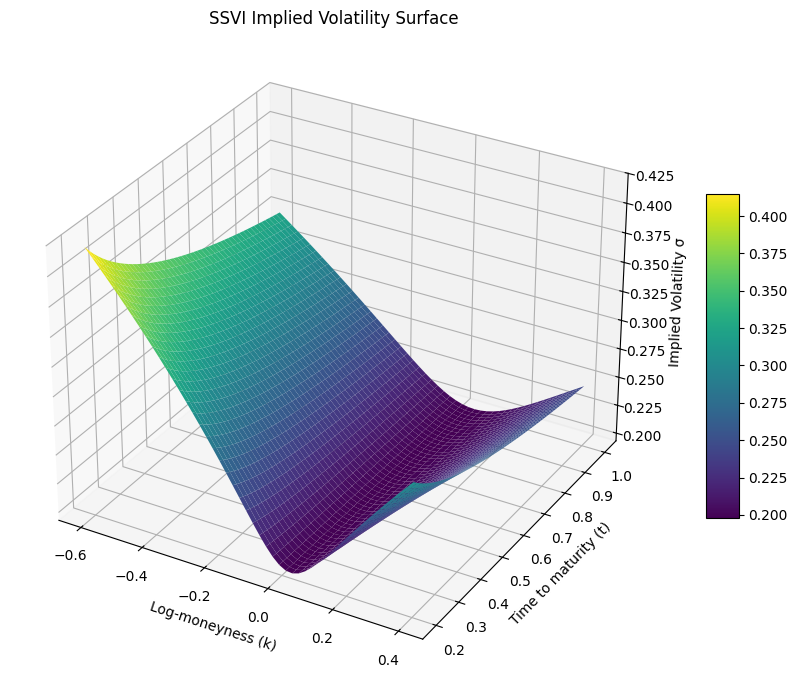

SSVI Parameters: {'eta': 1.6, 'lam': 0.4, 'rho': -0.15}


In [7]:
# Create and plot SSVI surface
ssvi = SSVIParameterization(eta=1.6, lam=0.4, rho=-0.15)
ssvi.plot_surface(k_range=(-0.6, 0.4), t_range=(0.2, 1.0))

print("SSVI Parameters:", ssvi.get_params_dict())

### 6.2 Heston Model Simulation

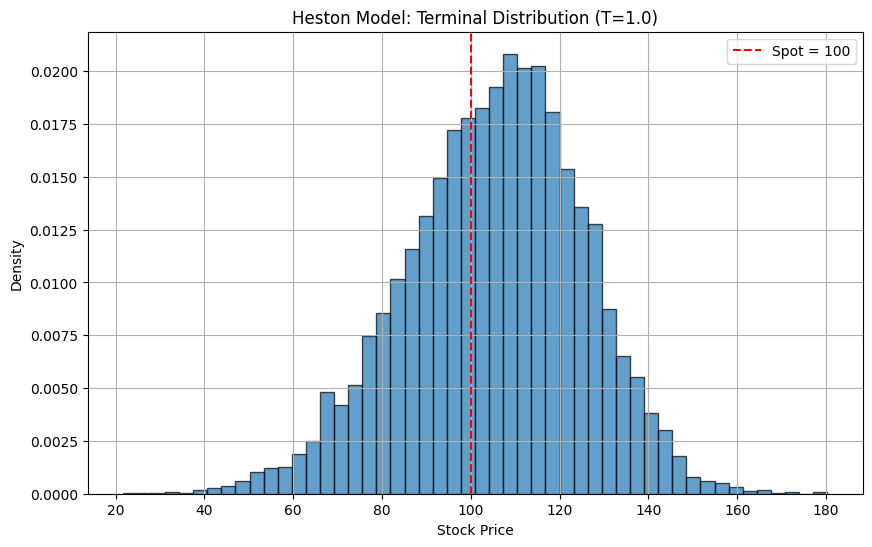

Mean: 105.31
Std: 19.98


In [8]:
# Initialize Heston model
heston = HestonModel(
    kappa=2.0,      # Mean reversion speed
    theta=0.04,     # Long-term variance
    sigma_v=0.3,    # Vol of vol
    rho=-0.7,       # Correlation
    v0=0.04,        # Initial variance
    mu=0.05,        # Drift
    device=device
)

# Simulate paths
S0 = 100
T = 1.0
N_paths = 10000

S_final = heston.simulate(S0, T, N_paths, steps=100)

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(S_final.detach().cpu().numpy(), bins=50, density=True, alpha=0.7, edgecolor='black')
plt.axvline(S0, color='red', linestyle='--', label=f'Spot = {S0}')
plt.xlabel('Stock Price')
plt.ylabel('Density')
plt.title(f'Heston Model: Terminal Distribution (T={T})')
plt.legend()
plt.grid(True)
plt.show()

print(f"Mean: {torch.mean(S_final).item():.2f}")
print(f"Std: {torch.std(S_final).item():.2f}")

### 6.3 Schrödinger Bridge Interpolation

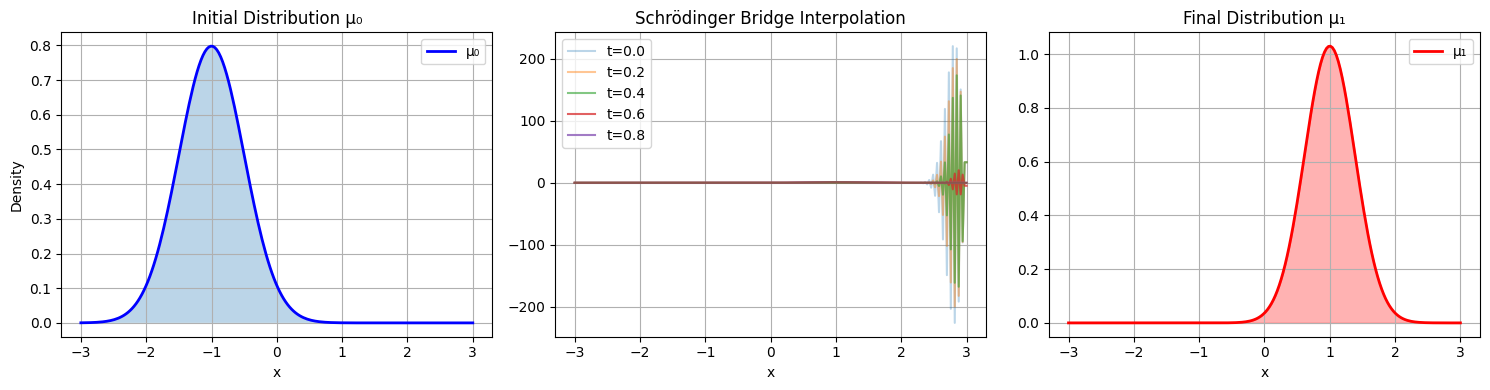

Approximate Wasserstein-2 distance: nan


In [9]:
# Demonstrate Schrödinger bridge interpolation
sb = SchrodingerBridge(epsilon=0.1, n_time_steps=50)

# Create initial and final distributions
x_grid = np.linspace(-3, 3, 200)
dx = x_grid[1] - x_grid[0]

# μ₀: Gaussian centered at -1
mu0 = np.exp(-(x_grid + 1)**2 / 0.5)
mu0 = mu0 / (np.sum(mu0) * dx)

# μ₁: Gaussian centered at +1
mu1 = np.exp(-(x_grid - 1)**2 / 0.3)
mu1 = mu1 / (np.sum(mu1) * dx)

# Compute interpolation
rho = sb.interpolate_oned(mu0, mu1, x_grid)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Initial
axes[0].plot(x_grid, mu0, 'b-', linewidth=2, label='μ₀')
axes[0].fill_between(x_grid, mu0, alpha=0.3)
axes[0].set_title('Initial Distribution μ₀')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True)

# Intermediate
for t_idx in [0, 10, 20, 30, 40, 49]:
    alpha = t_idx / 49
    axes[1].plot(x_grid, rho[t_idx], alpha=0.3 + 0.7*alpha,
                label=f't={alpha:.1f}' if t_idx % 10 == 0 else None)
axes[1].set_title('Schrödinger Bridge Interpolation')
axes[1].set_xlabel('x')
axes[1].legend()
axes[1].grid(True)

# Final
axes[2].plot(x_grid, mu1, 'r-', linewidth=2, label='μ₁')
axes[2].fill_between(x_grid, mu1, alpha=0.3, color='red')
axes[2].set_title('Final Distribution μ₁')
axes[2].set_xlabel('x')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Compute Wasserstein distance
w_dist = sb.compute_wasserstein_distance(mu0, mu1, x_grid)
print(f"Approximate Wasserstein-2 distance: {w_dist:.4f}")

### 6.4 Fetch Real Market Data

Fetched 250 options

Spot price: 693.715

Sample data:
     strike  maturity  impliedVolatility optionType
391   500.0  0.002738           1.675783       call
392   505.0  0.002738           1.732911       call
393   510.0  0.002738           1.696291       call
394   515.0  0.002738           1.622072       call
395   520.0  0.002738           1.603518       call
396   525.0  0.002738           1.570315       call
397   530.0  0.002738           1.411136       call
398   540.0  0.002738           1.325199       call
399   545.0  0.002738           1.282230       call
400   550.0  0.002738           1.289066       call


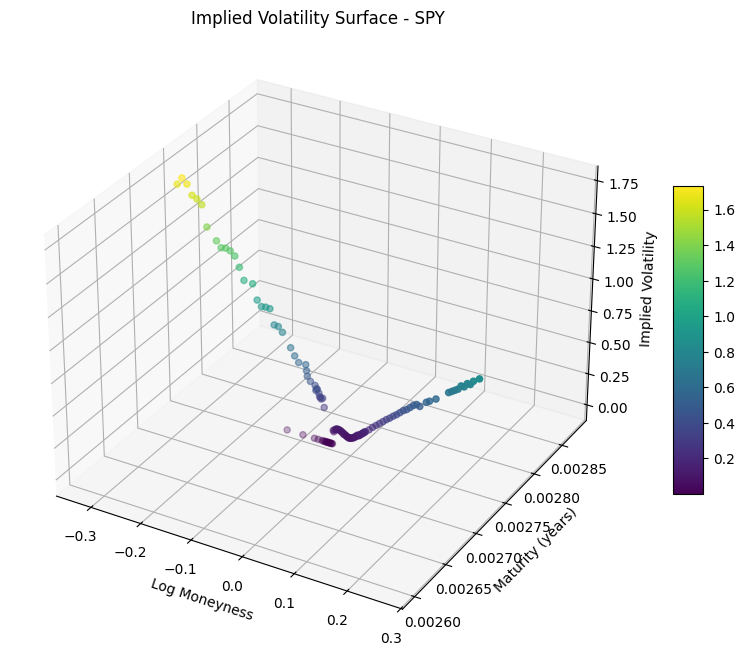

In [10]:
# Fetch real options data
fetcher = MarketDataFetcher()

try:
    # Fetch SPY options
    options_df = fetcher.fetch_options('SPY', max_expirations=3)

    print(f"Fetched {len(options_df)} options")
    print(f"\nSpot price: {options_df['spotPrice'].iloc[0]}")
    print(f"\nSample data:")
    print(options_df[['strike', 'maturity', 'impliedVolatility', 'optionType']].head(10))

    # Plot volatility surface
    fetcher.plot_volatility_surface()

except Exception as e:
    print(f"Error fetching data: {e}")
    print("Using synthetic data for demonstration...")

    # Create synthetic data
    np.random.seed(42)
    n_options = 100

    strikes = np.linspace(80, 120, n_options)
    maturities = np.random.choice([0.25, 0.5, 0.75, 1.0], n_options)

    # Create smile
    moneyness = strikes / 100
    atm_vol = 0.2
    skew = -0.1 * (moneyness - 1)
    smile = 0.05 * (moneyness - 1)**2
    implied_vols = atm_vol + skew + smile + np.random.normal(0, 0.01, n_options)

    options_df = pd.DataFrame({
        'strike': strikes,
        'maturity': maturities,
        'impliedVolatility': np.clip(implied_vols, 0.05, 0.5),
        'optionType': ['call'] * n_options,
        'spotPrice': 100.0,
        'underlying': 'SYNTH'
    })

    fetcher.data = options_df
    fetcher.plot_volatility_surface()

### 6.5 Calibrate Heston Model to Market Data

In [11]:
# Prepare calibration data
try:
    calib_data = fetcher.get_calibration_data(moneyness_range=(0.9, 1.1), min_volume=0)
except:
    calib_data = options_df

# Convert to calibration format
market_data = {
    'strikes': calib_data['strike'].values,
    'maturities': calib_data['maturity'].values,
    'prices': calib_data.get('price', calib_data['impliedVolatility'] * 100).values,
    'implied_vols': calib_data['impliedVolatility'].values,
    'types': calib_data['optionType'].values,
    'spot': calib_data['spotPrice'].iloc[0],
    'r': 0.05  # Assume 5% risk-free rate
}

print(f"Calibration data: {len(market_data['strikes'])} options")
print(f"Spot: {market_data['spot']}")
print(f"Maturity range: {market_data['maturities'].min():.3f} - {market_data['maturities'].max():.3f}")

# Initialize model with reasonable starting parameters
heston_model = HestonModel(
    kappa=1.5,
    theta=0.04,
    sigma_v=0.4,
    rho=-0.5,
    v0=0.04,
    mu=0.05,
    device=device
)

# Create calibrator
calibrator = SchrodingerVolatilityCalibrator(
    model=heston_model,
    epsilon=0.05,
    lr=0.02,
    device=device
)

# Run calibration (reduced epochs for demo)
print("\nStarting calibration...")
calibrated_params = calibrator.calibrate(
    market_data,
    num_epochs=50,
    loss_type='sinkhorn',
    verbose=True
)

print("\n=== Calibration Complete ===")
print("Final Parameters:")
for name, value in calibrated_params.items():
    print(f"  {name}: {value:.6f}")

Calibration data: 175 options
Spot: 693.715
Maturity range: 0.003 - 0.003

Starting calibration...
Epoch 0: Loss = 0.202749
  Params: κ=1.4804, θ=0.0200,                       σ_v=0.4200, ρ=-0.5200
Epoch 5: Loss = 0.203111
  Params: κ=1.5672, θ=0.0000,                       σ_v=0.4519, ρ=-0.4667
Epoch 10: Loss = 0.218031
  Params: κ=1.6657, θ=0.0000,                       σ_v=0.4766, ρ=-0.4094
Epoch 15: Loss = 0.205888
  Params: κ=1.7663, θ=0.0000,                       σ_v=0.4712, ρ=-0.3296
Epoch 20: Loss = 0.216257
  Params: κ=1.8682, θ=0.0000,                       σ_v=0.4946, ρ=-0.2708
Epoch 25: Loss = 0.197648
  Params: κ=1.9707, θ=0.0000,                       σ_v=0.5374, ρ=-0.2268
Epoch 30: Loss = 0.205695
  Params: κ=2.0719, θ=0.0000,                       σ_v=0.6095, ρ=-0.1764
Epoch 35: Loss = 0.199325
  Params: κ=2.1752, θ=0.0000,                       σ_v=0.6955, ρ=-0.1205
Epoch 40: Loss = 0.192663
  Params: κ=2.2786, θ=0.0000,                       σ_v=0.8027, ρ=-0.0942
Epo

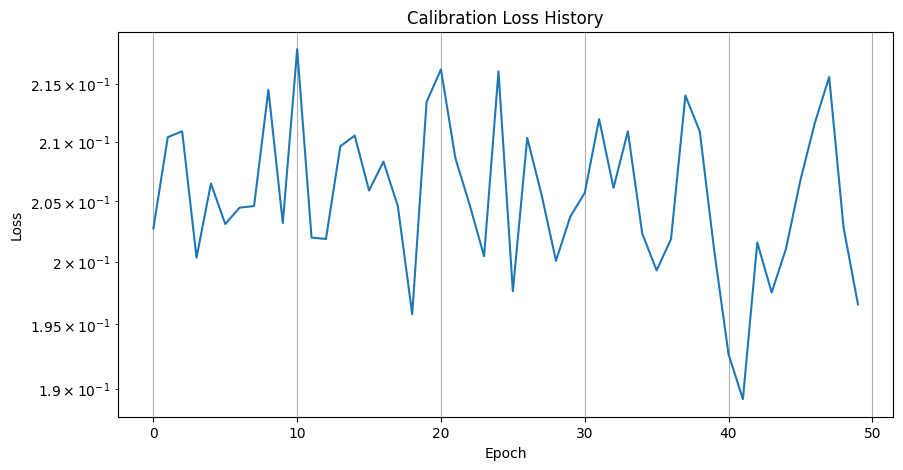

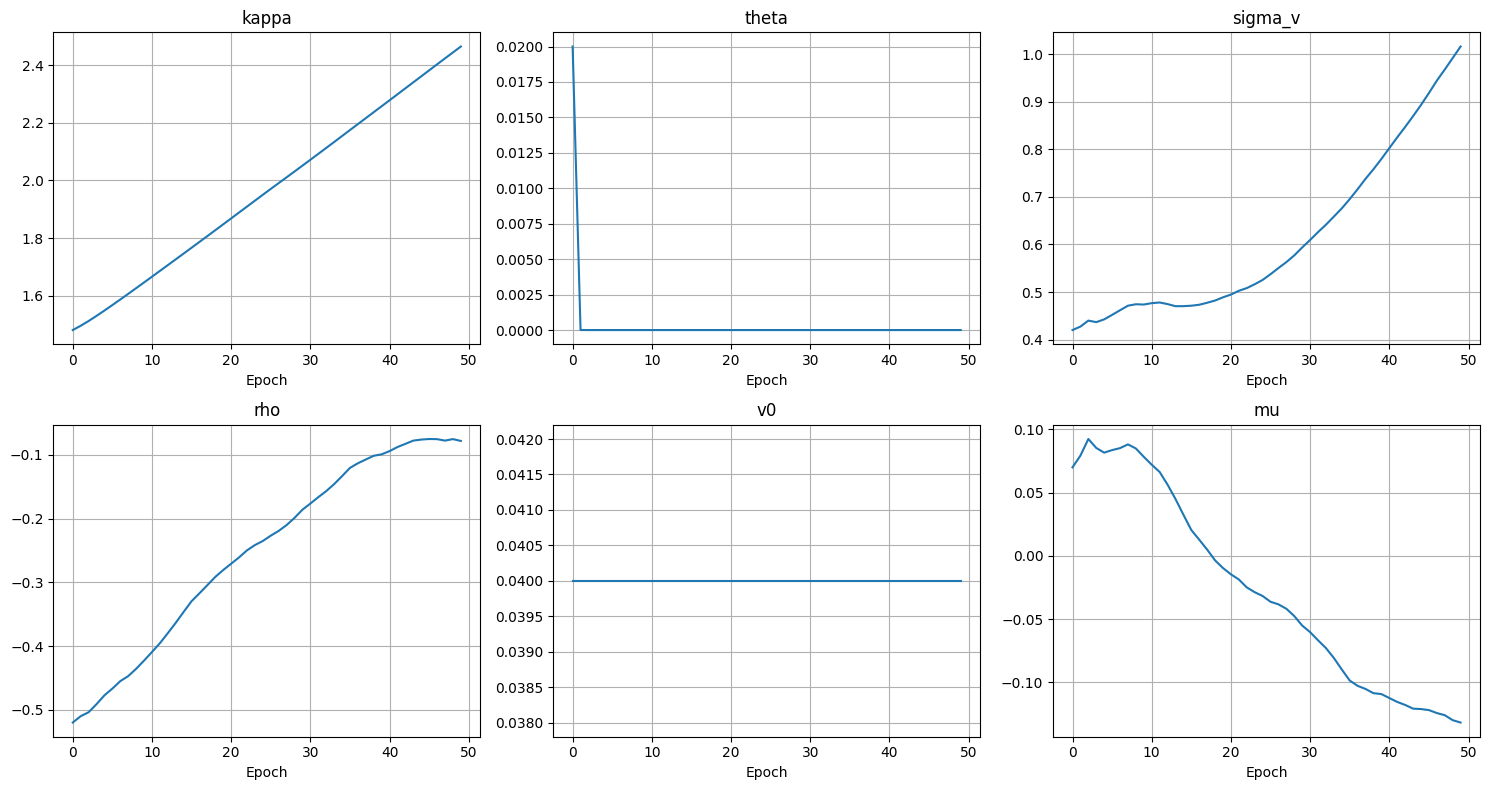

In [12]:
# Plot calibration results
calibrator.plot_loss_history()
calibrator.plot_param_evolution()

### 6.6 Graph-Based Neural Dynamics Demo

Graph: 20 vertices, 30 edges
Laplacian eigenvalues (first 5): [2.27553009e-15 2.79306125e-01 2.79306125e-01 9.31582112e-01
 9.31582112e-01]


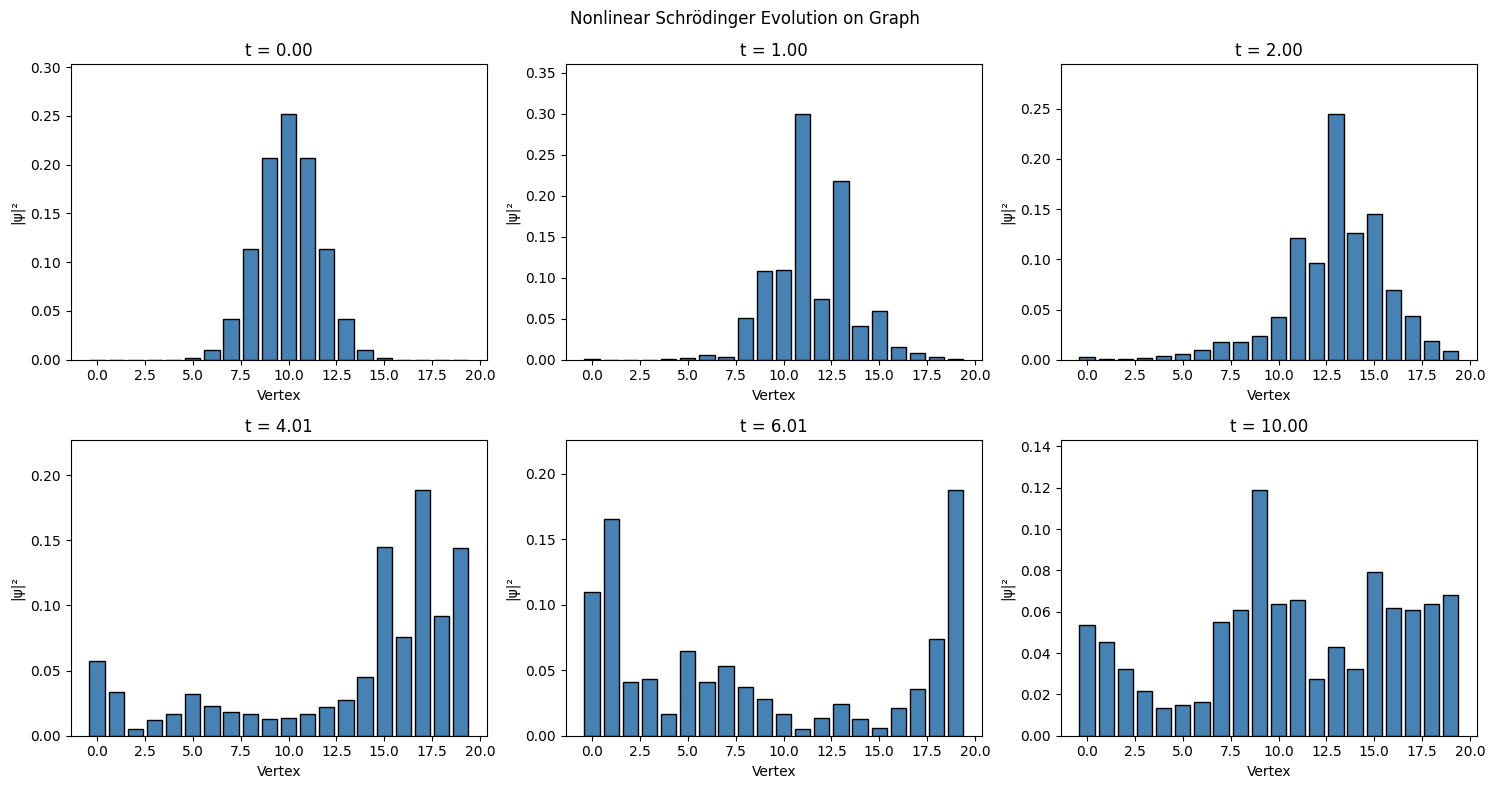

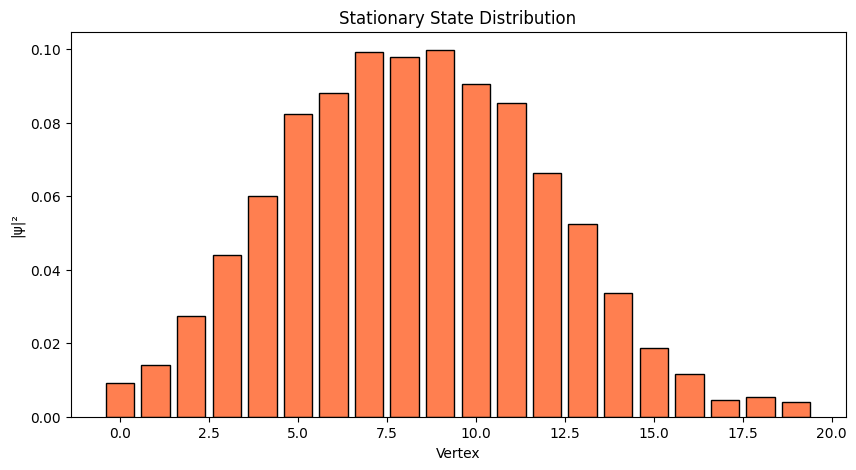

In [13]:
# Create a simple graph structure
n_vertices = 20

# Create a ring graph with some random edges
edge_list = [(i, (i+1) % n_vertices) for i in range(n_vertices)]
edge_list += [(i, (i+2) % n_vertices) for i in range(0, n_vertices, 2)]  # Add shortcuts

# Initialize Sobolev space
sobolev = GraphSobolevSpace(n_vertices, edge_list)

print(f"Graph: {n_vertices} vertices, {len(edge_list)} edges")
print(f"Laplacian eigenvalues (first 5): {sobolev.eigenvalues[:5]}")

# Initialize NLS
nls = NonlinearSchrodingerGraph(sobolev, gamma=0.1)

# Create initial condition (localized wave packet)
psi0 = np.exp(-((np.arange(n_vertices) - n_vertices//2)**2) / 10) * np.exp(1j * np.arange(n_vertices) * 0.5)
psi0 = psi0 / np.linalg.norm(psi0)

# Set edge weights (uniform for simplicity)
edge_weights = np.ones(len(edge_list))

# Evolve
t, trajectory = nls.evolve(psi0, edge_weights, (0, 10), n_steps=500)

# Plot evolution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

time_indices = [0, 50, 100, 200, 300, 499]

for idx, t_idx in enumerate(time_indices):
    ax = axes[idx // 3, idx % 3]
    psi = trajectory[:, t_idx]
    rho = np.abs(psi)**2

    ax.bar(range(n_vertices), rho, color='steelblue', edgecolor='black')
    ax.set_title(f't = {t[t_idx]:.2f}')
    ax.set_xlabel('Vertex')
    ax.set_ylabel('|ψ|²')
    ax.set_ylim(0, max(rho) * 1.2)

plt.suptitle('Nonlinear Schrödinger Evolution on Graph')
plt.tight_layout()
plt.show()

# Find stationary state
psi_stationary = nls.get_stationary_state(psi0, edge_weights, t_max=20)
rho_stationary = np.abs(psi_stationary)**2

plt.figure(figsize=(10, 5))
plt.bar(range(n_vertices), rho_stationary, color='coral', edgecolor='black')
plt.title('Stationary State Distribution')
plt.xlabel('Vertex')
plt.ylabel('|ψ|²')
plt.show()

## Part 7: Mathematical Summary and References

### Core Mathematical Framework

The unified framework connects several mathematical concepts:

#### 1. Controlled Schrödinger Equation on Graphs

$$i\lambda \partial_t \psi = -\frac{\lambda^2}{2} \Delta_\Sigma \psi + V_{\text{caSB}} \psi$$

where $\Delta_\Sigma$ is the weighted graph Laplacian and $V_{\text{caSB}}$ encodes the control objectives.

#### 2. Fokker-Planck Connection

For $\rho = |\psi|^2$, the Madelung transform yields:

$$\partial_t \rho + \nabla \cdot (\rho \mathbf{v}) = \frac{1}{2} \Delta_\Sigma \rho$$

with velocity $\mathbf{v} = \nabla S$ where $S$ is the phase of $\psi$.

#### 3. Optimal Transport Formulation

The calibration problem is:

$$\inf_{P \in \mathcal{P}(\mu_0, \mu_1)} \mathbb{E}^P\left[\int_0^1 L(\sigma_t^2) dt\right]$$

subject to martingale constraint $\mathbb{E}^P[X_t | \mathcal{F}_s] = X_s$.

#### 4. Schrödinger Bridge

The entropic regularization:

$$\inf_{P \in \mathcal{P}(\mu_0, \mu_1)} H(P | P_0)$$

where $H$ is relative entropy and $P_0$ is a reference measure.

### Key References

1. **Optimal Transport for Volatility Calibration**:
   - Guo, Loeper, Wang (2019): "Calibration of Local-Stochastic Volatility Models by Optimal Transport"
   - Zitridis (2025): "Martingale Optimal Transport and Martingale Schrödinger Bridges"

2. **Schrödinger Bridges**:
   - Henry-Labordère (2019): "From (Martingale) Schrödinger bridges to a new class of Stochastic Volatility Models"
   - Nutz, Wang, Zhang: "Martingale Schrödinger Bridges and Optimal Semistatic Portfolios"

3. **Fokker-Planck Methods**:
   - Stoykov (2024): "Calibration of Heston Stochastic Local Volatility Model by Numerical Solution of Nonlinear Fokker-Planck Equation"

4. **SSVI Parameterization**:
   - Gatheral, Jacquier (2014): "Arbitrage-free SVI volatility surfaces"

5. **FANN Framework**:
   - Pasechnyuk-Vilensky, Doroshenko (2025): "Feed-anywhere ANN (I) Steady Discrete → Diffusing on Graph Hidden States"

## Conclusion

This notebook implements a unified mathematical framework for stochastic volatility calibration that combines:

1. **Graph-based neural dynamics** (FANN framework) for learning hidden structures
2. **Optimal transport** for measure-preserving transformations
3. **Schrödinger bridges** for entropy-regularized interpolation
4. **Sinkhorn divergence** for efficient model-data comparison

The key insight is that volatility calibration can be viewed as an optimal transport problem between the model-implied and market-implied distributions, which can be efficiently solved using the mathematical machinery of Schrödinger bridges and entropic regularization.

### Future Extensions

1. Joint SPX-VIX calibration using dispersion-constrained MSB
2. Multi-asset correlation structure learning
3. Real-time calibration using online Sinkhorn algorithms
4. Neural network-based velocity field parameterization